In [1]:
import psycopg, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
conn = psycopg.connect(
    host='its_postgresql', 
    port=5432, 
    dbname='techstore_dw', 
    user='postgres', 
    password='postgres')
print('Connessione OK')

Connessione OK


In [2]:
df = pd.read_sql("""
SELECT categoria, COUNT(*) n
FROM fact_vendite fv
JOIN dim_prodotto dp ON fv.prodotto_sk = dp.prodotto_sk
GROUP BY categoria
""", conn)

df['prob'] = df['n'] / df['n'].sum()
df


/tmp/ipykernel_1442/1485526808.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


,categoria,n,prob
0,Accessori,28262,0.143572
1,Audio,22707,0.115352
2,Componenti,22345,0.113513
3,Gaming,22474,0.114169
4,Laptop,28087,0.142683
5,Smartphone,28092,0.142708
6,Smartwatch,22442,0.114006
7,Tablet,22440,0.113996


In [8]:
de_eta = pd.read_sql("""
select dc.fascia_eta, count(*) n
from fact_vendite fv
join dim_cliente dc on fv.cliente_sk = dc.cliente_sk
group by dc.fascia_eta
""", conn)

df['prob'] = df['n'] / df['n'].sum()
de_eta

/tmp/ipykernel_1442/2726987235.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  de_eta = pd.read_sql("""


,fascia_eta,n
0,18-24,18681
1,25-39,44811
2,40-59,61658
3,60+,71699


/tmp/ipykernel_1442/1964710230.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ct = pd.read_sql("""


<Axes: xlabel='categoria', ylabel='fascia_eta'>

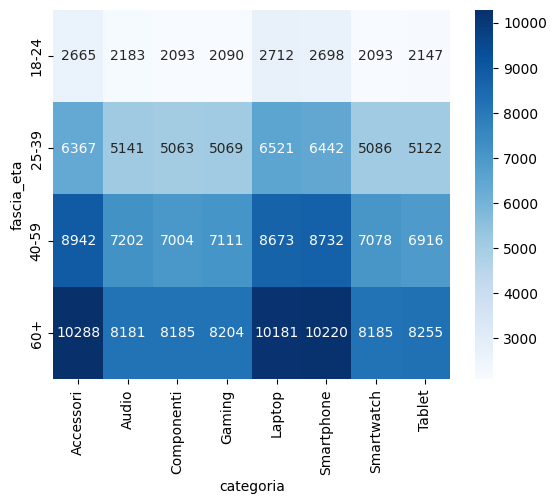

In [9]:
df_ct = pd.read_sql("""
SELECT fascia_eta, categoria, COUNT(*) n
FROM fact_vendite fv
JOIN dim_cliente dc ON fv.cliente_sk = dc.cliente_sk
JOIN dim_prodotto dp ON fv.prodotto_sk = dp.prodotto_sk
GROUP BY fascia_eta, categoria
""", conn)

pivot_ct = df_ct.pivot(
    index='fascia_eta', 
    columns='categoria', 
    values='n')
sns.heatmap(
    pivot_ct, 
    annot=True, # Scrive il numero dentro ogni cella. Senza questo parametro vedresti solo i colori.
    fmt='d',   # Significa “formato intero” (digit). Serve a dire che i valori sono numeri interi, non decimali.
    cmap='Blues')


In [16]:
# P(Laptop | 18-25)
df_ct

# (completare con P(A|B) = P(A,B) / P(B))

# Esercizio 4  P(Categoria | Fascia Età)

riga = pivot_ct.loc['18-24'] # series solo facia eta

totale = riga.sum() # totale su tutte categorie

prob_laptop = riga['Laptop'] / totale  

prob_laptop



np.float64(0.14517424120764413)

In [19]:
df_ct


# p(18-25|smartfone)

sm = pivot_ct['Smartphone']
totale = sm.sum()

prob_eta = sm / totale

prob_sm = prob_eta['18-24']
prob_sm


np.float64(0.09604157767335897)

In [20]:
# p(Laptop|18-24)

df = pd.read_sql("""
SELECT 
dc.fascia_eta,
dp.categoria, 
(sum(fv.ricavi)/sum(fv.quantita)) as costo
FROM fact_vendite fv
join dim_prodotto dp on fv.prodotto_sk = dp.prodotto_sk
join dim_cliente dc on fv.cliente_sk = dc.cliente_sk
group by  dp.categoria, dc.fascia_eta
""", conn)

df['fascia_costo'] = pd.cut(
    df['costo'],
    bins=[0, 300, 800, 2000],
    labels=['basso', 'medio', 'alto']
)
# P(Laptop | fascia 18-24 and fascia costo "alto")
fascia = '18-24'
fascia_costo = 'alto'


/tmp/ipykernel_1442/1970189952.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_costo_medio = pd.read_sql("""


,categoria,n,prob,fascia_costo
0,Accessori,28262,0.143572,medio
1,Audio,22707,0.115352,alto
2,Componenti,22345,0.113513,medio
3,Gaming,22474,0.114169,medio
4,Laptop,28087,0.142683,alto
5,Smartphone,28092,0.142708,alto
6,Smartwatch,22442,0.114006,medio
7,Tablet,22440,0.113996,alto


In [29]:
# Esercizio 6 – doppia condizione: P(Laptop | fascia 18–24 AND fascia costo "alto")

df = pd.read_sql("""
SELECT
    dc.fascia_eta,
    dp.categoria,
    SUM(fv.ricavi) / SUM(fv.quantita) AS costo_medio_categoria,
    COUNT(*) AS n
FROM fact_vendite fv
JOIN dim_cliente  dc ON fv.cliente_sk  = dc.cliente_sk
JOIN dim_prodotto dp ON fv.prodotto_sk = dp.prodotto_sk
GROUP BY dc.fascia_eta, dp.categoria
""", conn)

#  where dc.fascia_eta = '18-24'
#    and dp.categoria = 'Laptop'

# Fasce di costo prodotto per categoria
df['fascia_costo'] = pd.cut(
    df['costo_medio_categoria'],
    bins=[0, 300, 800, 2000],
    labels=['basso', 'medio', 'alto']
)
print(df)

# Esempio: P(Laptop | fascia 18–24 AND fascia costo "alto")

fascia = "18-24"
fascia_costo = "alto"
categoria = "Laptop"

subset = df[
    (df['fascia_eta'] == fascia) &
    (df['fascia_costo'] == fascia_costo)
]

totale = subset['n'].sum()

n_categoria = subset.loc[subset['categoria'] == categoria, 'n'].sum()

p = n_categoria / totale
p


   fascia_eta   categoria  costo_medio_categoria      n fascia_costo
0       18-24   Accessori             488.343449   2665        medio
1       18-24       Audio             869.286049   2183         alto
2       18-24  Componenti             580.087157   2093        medio
3       18-24      Gaming             757.875448   2090        medio
4       18-24      Laptop             900.657838   2712         alto
5       18-24  Smartphone             933.944612   2698         alto
6       18-24  Smartwatch             421.980134   2093        medio
7       18-24      Tablet            1127.498304   2147         alto
8       25-39   Accessori             475.971191   6367        medio
9       25-39       Audio             862.231921   5141         alto
10      25-39  Componenti             550.474741   5063        medio
11      25-39      Gaming             749.696258   5069        medio
12      25-39      Laptop             899.683707   6521         alto
13      25-39  Smartphone         

/tmp/ipykernel_1442/3256988256.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


np.float64(0.2784394250513347)

In [34]:
df = pd.read_sql("""
SELECT fascia_eta, categoria, COUNT(*) n
FROM fact_vendite fv
JOIN dim_cliente dc ON fv.cliente_sk = dc.cliente_sk
JOIN dim_prodotto dp ON fv.prodotto_sk = dp.prodotto_sk
GROUP BY fascia_eta, categoria
""", conn)


# ==================================================
# ESERCIZIO 7 – BAYES
# Calcolare P(Smartphone | 18-24)
# ==================================================

totale = df_ct['n'].sum()   # numero totale di vendite (tutte le fasce, tutte le categorie)

# ==================================================
# STEP 1 – PRIOR: P(Smartphone)
# ==================================================

condiz = df['categoria'] == 'Smartphone' 
smartfon = df[condiz]
print(smartfon)

n_smartphone = df_ct.loc[df_ct['categoria'] == 'Smartphone', 'n'].sum()
prior_smartphone = n_smartphone / totale
prior_smartphone

# ==================================================
# STEP 2 – LIKELIHOOD: P(18-24 | Smartphone)
# ==================================================

df_smartphone = df_ct[df_ct['categoria'] == 'Smartphone']

n_smartphone_18_24 = df_smartphone.loc[df_smartphone['fascia_eta'] == '18-24', 'n'].sum()
likelihood_18_24_given_smartphone = n_smartphone_18_24 / df_smartphone['n'].sum()
likelihood_18_24_given_smartphone

# ==================================================
# STEP 3 – EVIDENCE: P(18-24)
# ==================================================

n_18_24 = df_ct.loc[df_ct['fascia_eta'] == '18-24', 'n'].sum()
evidence_18_24 = n_18_24 / totale
evidence_18_24

# ==================================================
# STEP 4 – POSTERIOR: Bayes
#             P(Smartphone | 18-24)
# ==================================================

posterior_smartphone_given_18_24 = (
    likelihood_18_24_given_smartphone * prior_smartphone
) / evidence_18_24

posterior_smartphone_given_18_24


   fascia_eta   categoria      n
5       18-24  Smartphone   2698
13      25-39  Smartphone   6442
21      40-59  Smartphone   8732
29        60+  Smartphone  10220


/tmp/ipykernel_1442/1549504963.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


np.float64(0.14442481665863713)